 ADVANCED MARKOWITZ PORTFOLIO OPTIMIZER
 Download dati dal 2005-01-01 al 2025-01-01...

 Qualità Dati:
  AGG: 0.0% dati mancanti
  DBC: 5.5% dati mancanti
  DBO: 10.0% dati mancanti
  FEZ: 0.0% dati mancanti
  GLD: 0.0% dati mancanti
  IEF: 0.0% dati mancanti
  IYR: 0.0% dati mancanti
  SPY: 0.0% dati mancanti
  VGK: 0.9% dati mancanti
  VNQ: 0.0% dati mancanti
  VWO: 0.9% dati mancanti

 ETF utilizzati (11): ['AGG', 'DBC', 'DBO', 'FEZ', 'GLD', 'IEF', 'IYR', 'SPY', 'VGK', 'VNQ', 'VWO']

 STATISTICHE ASSET INDIVIDUALI (Top 5 per Sharpe)
        Rendimento Annuo (%)  Volatilità Annua (%)  Sharpe Ratio  \
Ticker                                                             
SPY                    11.63                 19.03          0.37   
GLD                    10.20                 17.54          0.32   
VNQ                    10.91                 29.22          0.22   
IYR                     9.90                 28.33          0.19   
VWO                     8.99                 26.53

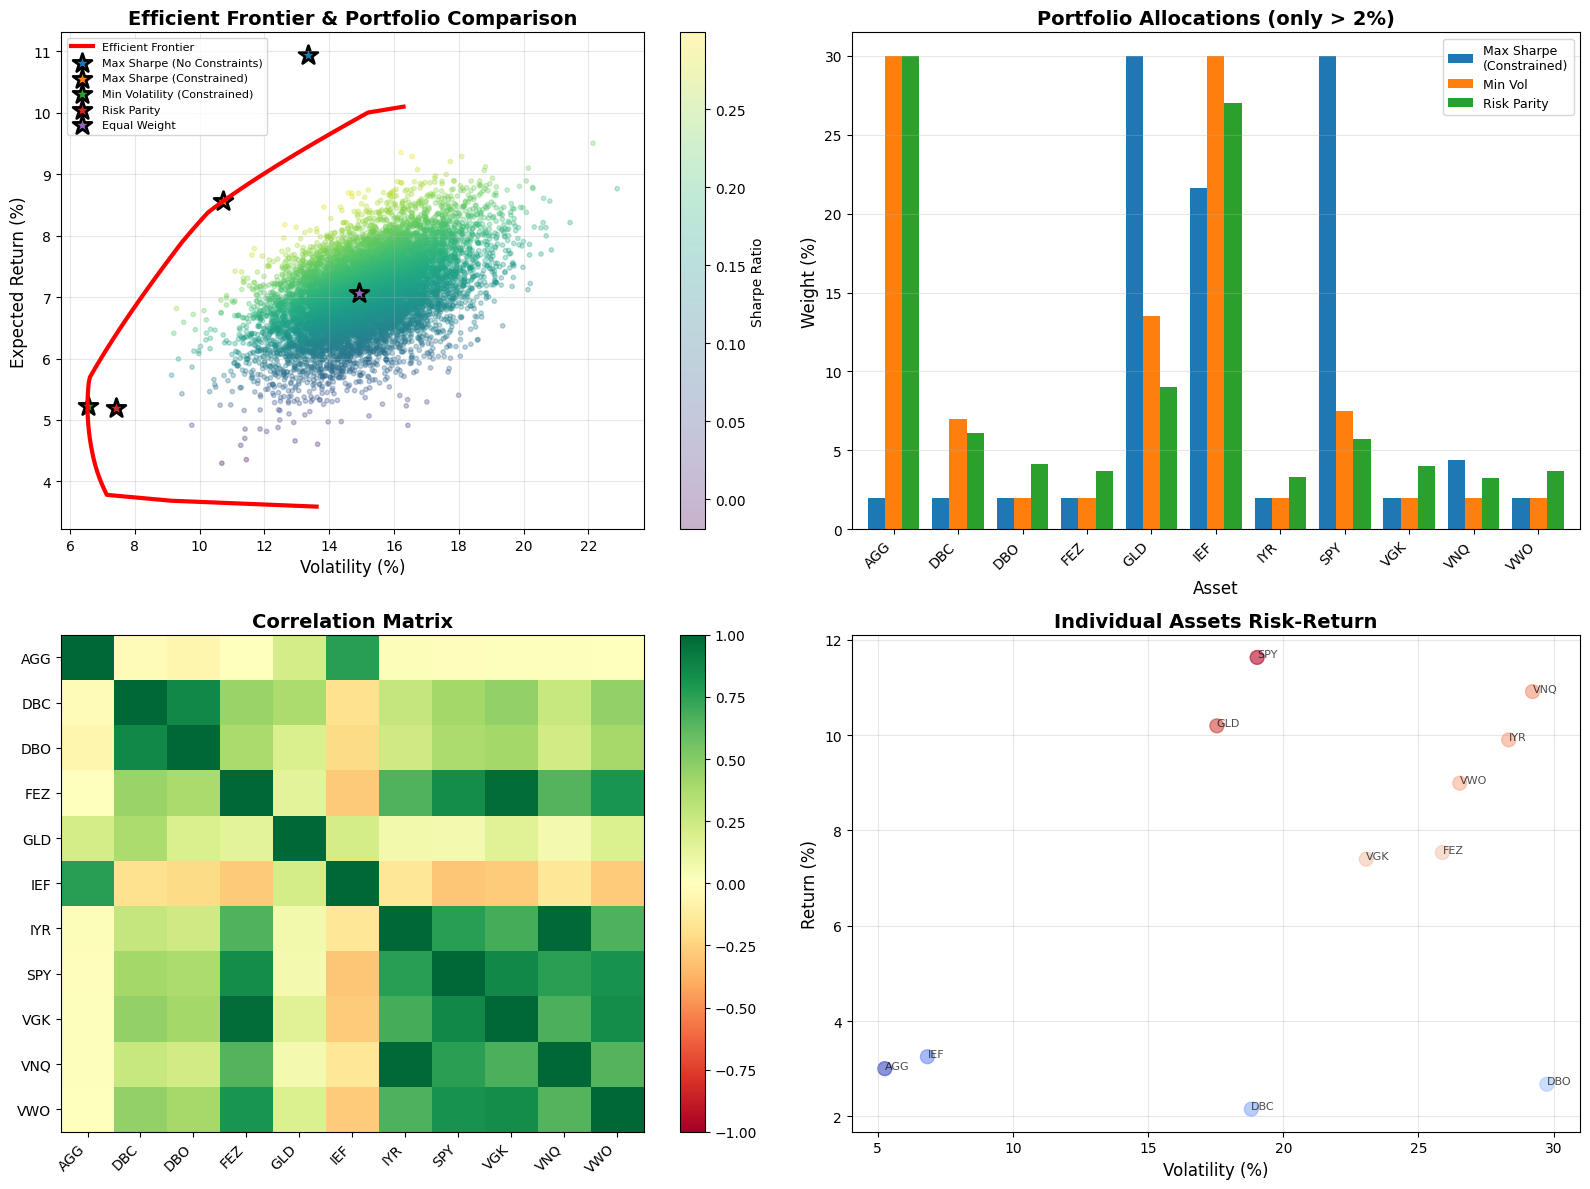


ANALISI COMPLETATA


In [ ]:


import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# configuro
CONFIG = {
    'start_date': "2005-01-01",
    'end_date': "2025-01-01",
    'risk_free_rate': 0.045,
    'min_weight': 0.02,      # Min 2% per asset (diversificazione forzata)
    'max_weight': 0.30,      # Max 30% per asset (limita concentrazione)
    'rebalance_freq': 'Q',   # Trimestrale
    'num_simulations': 10000 # Per Monte Carlo
}

assets = {
    "SPY": "S&P 500 (USA)",
    "VGK": "Vanguard FTSE Europe",
    "FEZ" : "SPDR EURO STOXX 50 ETF",
    "VWO": "FTSE Emerging Markets",
    "AGG": "iShares Core US Aggregate Bond",
    "IEF": "7–10 Yr Treasury",
    "GLD": "Gold",
    "DBO": "Treasury Bond",
    "DBC": "Corporate Bond",
    "VNQ": "US Real Estate",
    "IYR": "US Real Estate (iShares)",

}


# download dati
def download_and_clean_data(tickers, start, end):
    """Download dati con gestione robusta degli errori"""
    print(f" Download dati dal {start} al {end}...")

    data_raw = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=True)

    # Gestione struttura dati
    if isinstance(data_raw.columns, pd.MultiIndex):
        data = data_raw['Close']
    else:
        data = data_raw

    # Statistiche qualità dati
    missing_pct = data.isnull().sum() / len(data) * 100
    print(f"\n Qualità Dati:")
    for ticker in data.columns:
        print(f"  {ticker}: {missing_pct[ticker]:.1f}% dati mancanti")

    # Rimuovi asset con >30% dati mancanti
    threshold = len(data) * 0.3
    data = data.dropna(thresh=len(data) - threshold, axis=1)

    # Fill missing values
    data = data.fillna(method='ffill').fillna(method='bfill')

    print(f"\n ETF utilizzati ({len(data.columns)}): {list(data.columns)}")
    return data

# inizio analisi
def calculate_statistics(data, risk_free_rate):
    """Calcola statistiche complete con metriche avanzate"""
    returns = data.pct_change().dropna()

    stats = pd.DataFrame({
        'Rendimento Annuo (%)': returns.mean() * 252 * 100,
        'Volatilità Annua (%)': returns.std() * np.sqrt(252) * 100,
        'Sharpe Ratio': (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252)),
        'Max Drawdown (%)': [(data[col] / data[col].cummax() - 1).min() * 100 for col in data.columns],
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurtosis(),
        'VaR 95% (%)': returns.quantile(0.05) * 100
    }, index=data.columns)

    return returns, stats

# portafogli-perfomance-sharpe-volatility
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate):
    """Calcola performance completa del portafoglio"""
    returns = np.dot(weights, mean_returns)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (returns - risk_free_rate) / std if std > 0 else 0
    return returns, std, sharpe

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]

def portfolio_volatility(weights, mean_returns, cov_matrix, risk_free_rate):
    return portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[1]

# inserisco vincoli e ottimizzo
def optimize_portfolio(mean_returns, cov_matrix, risk_free_rate, min_w=0, max_w=1):
    """Ottimizzazione con vincoli realistici"""
    n = len(mean_returns)
    bounds = tuple((min_w, max_w) for _ in range(n))
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    initial_guess = np.array([1./n] * n)

    # Max Sharpe
    opt_sharpe = minimize(
        negative_sharpe, initial_guess,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 1000}
    )

    # Min Volatility
    opt_var = minimize(
        portfolio_volatility, initial_guess,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 1000}
    )

    # Max Return (per rendimento target)
    max_ret = mean_returns.max()
    constraints_maxret = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - max_ret * 0.95}
    )
    opt_maxret = minimize(
        portfolio_volatility, initial_guess,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method='SLSQP', bounds=bounds, constraints=constraints_maxret,
        options={'maxiter': 1000}
    )

    # Risk Parity (contributi al rischio uguali)
    weights_rp = risk_parity_portfolio(cov_matrix, bounds)

    return {
        'max_sharpe': opt_sharpe,
        'min_var': opt_var,
        'max_return': opt_maxret,
        'risk_parity': weights_rp
    }

def risk_parity_portfolio(cov_matrix, bounds):
    """Portfolio Risk Parity: contributi al rischio uguali"""
    n = len(cov_matrix)

    def risk_contribution(weights):
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        marginal_contrib = np.dot(cov_matrix, weights)
        risk_contrib = weights * marginal_contrib / portfolio_vol
        target = portfolio_vol / n
        return np.sum((risk_contrib - target)**2)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    initial_guess = np.array([1./n] * n)

    opt = minimize(
        risk_contribution, initial_guess,
        method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 1000}
    )

    return opt.x if opt.success else initial_guess

# monte carlo simulation
def monte_carlo_portfolios(mean_returns, cov_matrix, risk_free_rate, num_sims=10000):
    """Genera portafogli random per visualizzazione"""
    n = len(mean_returns)
    results = np.zeros((4, num_sims))

    for i in range(num_sims):
        weights = np.random.random(n)
        weights /= weights.sum()

        ret, vol, sharpe = portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)
        results[0,i] = ret
        results[1,i] = vol
        results[2,i] = sharpe
        results[3,i] = weights.max()  # Concentrazione massima

    return results

# backtest
def backtest_portfolio(data, weights, rebalance_freq='Q'):
    """Backtest con rebalancing periodico"""
    returns = data.pct_change().dropna()

    # Rebalancing dates
    rebalance_dates = returns.resample(rebalance_freq).last().index

    portfolio_value = [100]  # Start con 100
    for i in range(len(returns)):
        if i == 0:
            continue

        # Calcola return giornaliero
        daily_return = np.dot(weights, returns.iloc[i])
        portfolio_value.append(portfolio_value[-1] * (1 + daily_return))

    portfolio_series = pd.Series(portfolio_value, index=returns.index)

    # Metriche
    total_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0] - 1) * 100
    annual_return = (portfolio_series.iloc[-1] / portfolio_series.iloc[0]) ** (252 / len(portfolio_series)) - 1
    max_dd = ((portfolio_series / portfolio_series.cummax()) - 1).min() * 100

    return portfolio_series, {
        'Total Return (%)': total_return,
        'Annualized Return (%)': annual_return * 100,
        'Max Drawdown (%)': max_dd
    }

# execution
print("="*60)
print(" ADVANCED MARKOWITZ PORTFOLIO OPTIMIZER")
print("="*60)

# Download dati
data = download_and_clean_data(
    list(assets.keys()),
    CONFIG['start_date'],
    CONFIG['end_date']
)

# Statistiche
returns, stats = calculate_statistics(data, CONFIG['risk_free_rate'])
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print("\n" + "="*60)
print(" STATISTICHE ASSET INDIVIDUALI (Top 5 per Sharpe)")
print("="*60)
print(stats.sort_values('Sharpe Ratio', ascending=False).head().round(2))

# Ottimizzazione senza vincoli ho comunque dei dubbi, !!da rivedere!!
print("\n" + "="*60)
print(" OTTIMIZZAZIONE SENZA VINCOLI (Min 0%, Max 100%)")
print("="*60)
opt_unconstrained = optimize_portfolio(mean_returns, cov_matrix, CONFIG['risk_free_rate'])

# Ottimizzazione con vincoli
print("\n" + "="*60)
print(f" OTTIMIZZAZIONE CON VINCOLI (Min {CONFIG['min_weight']*100}%, Max {CONFIG['max_weight']*100}%)")
print("="*60)
opt_constrained = optimize_portfolio(
    mean_returns, cov_matrix, CONFIG['risk_free_rate'],
    CONFIG['min_weight'], CONFIG['max_weight']
)

# Risultati
portfolios = {
    'Max Sharpe (No Constraints)': opt_unconstrained['max_sharpe'].x,
    'Max Sharpe (Constrained)': opt_constrained['max_sharpe'].x,
    'Min Volatility (Constrained)': opt_constrained['min_var'].x,
    'Risk Parity': opt_constrained['risk_parity'],
    'Equal Weight': np.array([1/len(mean_returns)] * len(mean_returns))
}

# Summary table
summary = pd.DataFrame({
    'Return (%)': [portfolio_performance(w, mean_returns, cov_matrix, CONFIG['risk_free_rate'])[0]*100
                   for w in portfolios.values()],
    'Volatility (%)': [portfolio_performance(w, mean_returns, cov_matrix, CONFIG['risk_free_rate'])[1]*100
                       for w in portfolios.values()],
    'Sharpe': [portfolio_performance(w, mean_returns, cov_matrix, CONFIG['risk_free_rate'])[2]
               for w in portfolios.values()],
    'Max Weight (%)': [w.max()*100 for w in portfolios.values()],
    'Min Weight (%)': [w.min()*100 for w in portfolios.values()],
    'Num Assets > 5%': [(w > 0.05).sum() for w in portfolios.values()]
}, index=portfolios.keys())

print("\n" + "="*60)
print("CONFRONTO PORTAFOGLI")
print("="*60)
print(summary.round(2))

# Weights table (solo asset significativi)
print("\n" + "="*60)
print(" ALLOCAZIONI (solo asset > 5%)")
print("="*60)
weights_df = pd.DataFrame(portfolios, index=mean_returns.index) * 100
weights_df = weights_df[(weights_df > 5).any(axis=1)]
print(weights_df.round(1))

# Monte Carlo
print("\n Generazione Monte Carlo portfolios...")
mc_results = monte_carlo_portfolios(mean_returns, cov_matrix, CONFIG['risk_free_rate'], CONFIG['num_simulations'])

# Efficient Frontier
print(" Calcolo frontiera efficiente")
returns_range = np.linspace(mean_returns.min(), mean_returns.max(), 100)
frontier_points = []
n = len(mean_returns)
bounds = tuple((CONFIG['min_weight'], CONFIG['max_weight']) for _ in range(n))

for target in returns_range:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - target}
    )
    opt = minimize(
        portfolio_volatility, np.array([1./n]*n),
        args=(mean_returns, cov_matrix, CONFIG['risk_free_rate']),
        method='SLSQP', bounds=bounds, constraints=constraints
    )
    if opt.success:
        frontier_points.append((target, opt.fun))

frontier = pd.DataFrame(frontier_points, columns=['Return', 'Volatility'])

# grafici
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Efficient Frontier con Monte Carlo
ax1 = axes[0, 0]
scatter = ax1.scatter(mc_results[1,:]*100, mc_results[0,:]*100,
                     c=mc_results[2,:], cmap='viridis', alpha=0.3, s=10)
ax1.plot(frontier['Volatility']*100, frontier['Return']*100,
         'r-', linewidth=3, label='Efficient Frontier')

for name, weights in portfolios.items():
    perf = portfolio_performance(weights, mean_returns, cov_matrix, CONFIG['risk_free_rate'])
    ax1.scatter(perf[1]*100, perf[0]*100, s=200, marker='*',
               edgecolors='black', linewidth=2, label=name)

ax1.set_xlabel('Volatility (%)', fontsize=12)
ax1.set_ylabel('Expected Return (%)', fontsize=12)
ax1.set_title('Efficient Frontier & Portfolio Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Sharpe Ratio')

# Plot 2: Asset Allocation Comparison
ax2 = axes[0, 1]
weights_plot = pd.DataFrame({
    'Max Sharpe\n(Constrained)': portfolios['Max Sharpe (Constrained)'],
    'Min Vol': portfolios['Min Volatility (Constrained)'],
    'Risk Parity': portfolios['Risk Parity']
}, index=mean_returns.index) * 100
weights_plot[weights_plot < 2] = 0  # Hide < 2%
weights_plot = weights_plot[weights_plot.sum(axis=1) > 0]
weights_plot.plot(kind='bar', stacked=False, ax=ax2, width=0.8)
ax2.set_title('Portfolio Allocations (only > 2%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weight (%)', fontsize=12)
ax2.set_xlabel('Asset', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 3: Correlation Matrix
ax3 = axes[1, 0]
corr = returns.corr()
im = ax3.imshow(corr, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
ax3.set_xticks(range(len(corr)))
ax3.set_yticks(range(len(corr)))
ax3.set_xticklabels(corr.columns, rotation=45, ha='right')
ax3.set_yticklabels(corr.columns)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax3)

# Plot 4: Risk Return Scatter
ax4 = axes[1, 1]
ax4.scatter(stats['Volatilità Annua (%)'], stats['Rendimento Annuo (%)'],
           s=100, alpha=0.6, c=stats['Sharpe Ratio'], cmap='coolwarm')
for idx, row in stats.iterrows():
    ax4.annotate(idx, (row['Volatilità Annua (%)'], row['Rendimento Annuo (%)']),
                fontsize=8, alpha=0.7)
ax4.set_xlabel('Volatility (%)', fontsize=12)
ax4.set_ylabel('Return (%)', fontsize=12)
ax4.set_title('Individual Assets Risk-Return', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_analysis.png', dpi=300, bbox_inches='tight')
print("\n Grafici salvati'")
plt.show()

print("\n" + "="*60)
print("ANALISI COMPLETATA")
print("="*60)